In [2]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Path to your dataset (update if needed)
dataset_path = "/content/drive/MyDrive/Liver Biopsies"

# 3. Check number of images in each subfolder
classes = ["Healthy", "Inflammation", "Steatosis", "Ballooning", "Fibrosis"]

print("Number of images per class:\n")
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    if os.path.exists(cls_path):
        num_files = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
        print(f"{cls} : {num_files}")
    else:
        print(f"{cls} folder not found!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Number of images per class:

Healthy : 780
Inflammation : 780
Steatosis : 780
Ballooning : 778
Fibrosis : 739


In [3]:
# Run once in Colab / notebook environment
!pip install -q timm              # model zoo (regnet)
!pip install -q grad-cam          # pytorch_grad_cam
!pip install -q torchmetrics      # optional metrics utilities


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 83.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 23.0 MB/s eta 0:00:00


In [4]:
# Cell 1
import os
import random
from pathlib import Path
from datetime import datetime
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Grad-CAM imports
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from PIL import Image

# reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Mount Google Drive (Colab)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [5]:
# Cell 2 - update this path to where your "Liver Biopsies" folder lives in Drive
DATASET_ROOT = "/content/drive/MyDrive/Liver Biopsies"
assert os.path.exists(DATASET_ROOT), f"Dataset path not found: {DATASET_ROOT}"

# Print counts per top-level class folder
print("Top-level folders and file counts:")
for d in sorted(os.listdir(DATASET_ROOT)):
    p = os.path.join(DATASET_ROOT, d)
    if os.path.isdir(p):
        n = sum([1 for f in os.listdir(p) if os.path.isfile(os.path.join(p, f))])
        print(f"  {d} : {n}")

Top-level folders and file counts:
  Ballooning : 778
  Fibrosis : 739
  Healthy : 780
  Inflammation : 780
  Steatosis : 780


In [6]:
# Cell 3 - transforms and dataloaders
IMG_SIZE = 224
BATCH_SIZE = 16     # reduce to 8/4 if OOM
NUM_WORKERS = 4
VAL_SPLIT = 0.20

# Train transforms (basic + augmentation)
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.12, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# Validation transforms (deterministic)
val_transforms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# Use ImageFolder on the top-level dataset (assumes each class folder directly under DATASET_ROOT)
base_dataset = datasets.ImageFolder(DATASET_ROOT, transform=train_transforms)
class_names = base_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)
print("Total samples in dataset:", len(base_dataset))

# Build stratified train/val split using sample indices
targets = [s[1] for s in base_dataset.samples]
indices = np.arange(len(base_dataset))

train_idx, val_idx = train_test_split(
    indices, test_size=VAL_SPLIT, stratify=targets, random_state=42
)

train_dataset = Subset(datasets.ImageFolder(DATASET_ROOT, transform=train_transforms), train_idx)
val_dataset   = Subset(datasets.ImageFolder(DATASET_ROOT, transform=val_transforms), val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")


Classes: ['Ballooning', 'Fibrosis', 'Healthy', 'Inflammation', 'Steatosis']
Total samples in dataset: 3856
Train size: 3084 | Val size: 772


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [7]:
# Cell 4 - model creation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def create_regnet(num_classes, model_name="regnetx_002.pycls_in1k", pretrained=True):
    try:
        model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
        return model
    except Exception as e:
        print("Error creating model:", e)
        # If the primary model fails, fallback to a smaller regnet variant.
        # Note: As of current timm versions, regnetx_200mf and regnetx_400mf might not be directly available.
        # We'll use a verified available model from the list if the primary fails.
        fallback = "regnetx_002.pycls_in1k"
        print(f"Falling back to {fallback}")
        try:
            model = timm.create_model(fallback, pretrained=pretrained, num_classes=num_classes)
            return model
        except Exception as e_fallback:
            print(f"Error creating fallback model {fallback}:", e_fallback)
            print("Available RegNet models in timm:")
            # List available regnet models
            available_models = timm.list_models('regnet*', pretrained=True)
            print(available_models)
            raise e_fallback # Re-raise the exception if fallback also fails

model = create_regnet(num_classes=num_classes, model_name="regnetx_002.pycls_in1k", pretrained=True)
model = model.to(device)
print(model)

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/10.8M [00:00<?, ?B/s]

RegNet(
  (stem): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (s1): RegStage(
    (b1): Bottleneck(
      (conv1): ConvNormAct(
        (conv): Conv2d(32, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNormAct2d(
          24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
      )
      (conv2): ConvNormAct(
        (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=3, bias=False)
        (bn): BatchNormAct2d(
          24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
      )
      (se): Identity()
      (conv3): ConvNormAct(
     

In [8]:
# Cell 5 - training utilities
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
EPOCHS = 12
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)  # decays across epochs
scaler = torch.cuda.amp.GradScaler()

# Optional MixUp (set USE_MIXUP=True in training loop to enable)
def mixup_data(x, y, alpha=0.4):
    '''Returns mixed inputs, pairs of targets, and lambda'''
    if alpha <= 0:
        return x, y, None, 1.0
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

/tmp/ipython-input-1060552510.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [9]:
# Cell 6 - training & validation functions
USE_MIXUP = False      # toggle this to True to enable MixUp
MIXUP_ALPHA = 0.4

def train_one_epoch(model, loader, optimizer, criterion, device, scaler, use_mixup=False, alpha=0.4):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0
    pbar = tqdm(loader, desc="Train")
    for inputs, labels in pbar:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        if use_mixup:
            inputs, targets_a, targets_b, lam = mixup_data(inputs, labels, alpha)
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)
            # accuracy (approx) - evaluate predicted against targets_a (not precise but gives sense)
            preds = outputs.argmax(dim=1)
            running_corrects += (lam * (preds == targets_a).sum().item() + (1 - lam) * (preds == targets_b).sum().item())
            total += inputs.size(0)
        else:
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)
            running_corrects += (preds == labels).sum().item()
            total += inputs.size(0)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        pbar.set_postfix(loss=running_loss/total, acc=running_corrects/total)
    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        pbar = tqdm(loader, desc="Val")
        for inputs, labels in pbar:
            inputs = inputs.to(device)
            labels = labels.to(device)
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += (preds == labels).sum().item()
            total += inputs.size(0)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            pbar.set_postfix(loss=running_loss/total, acc=running_corrects/total)

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return running_loss/total, running_corrects/total, all_preds, all_labels

In [10]:
# Cell 7 - run training
save_dir = "/content/drive/MyDrive/regnet_checkpoints"
os.makedirs(save_dir, exist_ok=True)
best_acc = 0.0
history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}

for epoch in range(1, EPOCHS + 1):
    print(f"\n=== Epoch {epoch}/{EPOCHS} ===")
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler, use_mixup=USE_MIXUP, alpha=MIXUP_ALPHA)
    val_loss, val_acc, val_preds, val_labels = validate(model, val_loader, criterion, device)
    scheduler.step()
    print(f"Epoch {epoch} Train loss={train_loss:.4f} acc={train_acc:.4f} | Val loss={val_loss:.4f} acc={val_acc:.4f}")

    history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        ckpt_path = os.path.join(save_dir, f"regnet_best_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth")
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc,
            "class_names": class_names
        }, ckpt_path)
        print(f"Saved best model -> {ckpt_path}")


=== Epoch 1/12 ===


Train:   0%|          | 0/193 [00:00<?, ?it/s]/tmp/ipython-input-4064737926.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Val:   0%|          | 0/49 [00:00<?, ?it/s]/tmp/ipython-input-4064737926.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Val: 100%|██████████| 49/49 [00:55<00:00,  1.14s/it, acc=0.931, loss=0.232]


Epoch 1 Train loss=0.5276 acc=0.8350 | Val loss=0.2319 acc=0.9313
Saved best model -> /content/drive/MyDrive/regnet_checkpoints/regnet_best_20251003_094904.pth

=== Epoch 2/12 ===


Val: 100%|██████████| 49/49 [00:05<00:00,  8.71it/s, acc=0.939, loss=0.197]


Epoch 2 Train loss=0.2494 acc=0.9219 | Val loss=0.1966 acc=0.9391
Saved best model -> /content/drive/MyDrive/regnet_checkpoints/regnet_best_20251003_094951.pth

=== Epoch 3/12 ===


...

Epoch 10 Train loss=0.0665 acc=0.9783 | Val loss=0.1453 acc=0.9547

=== Epoch 11/12 ===


Val: 100%|██████████| 49/49 [00:05<00:00,  8.73it/s, acc=0.956, loss=0.152]


Epoch 11 Train loss=0.0597 acc=0.9822 | Val loss=0.1518 acc=0.9560

=== Epoch 12/12 ===


Val: 100%|██████████| 49/49 [00:05<00:00,  8.81it/s, acc=0.953, loss=0.146]

Epoch 12 Train loss=0.0696 acc=0.9780 | Val loss=0.1455 acc=0.9534


Validation Classification Report:
              precision    recall  f1-score   support

  Ballooning     0.9669    0.9359    0.9511       156
    Fibrosis     1.0000    1.0000    1.0000       148
     Healthy     0.9161    0.9103    0.9132       156
Inflammation     0.9231    0.9231    0.9231       156
   Steatosis     0.9630    1.0000    0.9811       156

    accuracy                         0.9534       772
   macro avg     0.9538    0.9538    0.9537       772
weighted avg     0.9533    0.9534    0.9532       772



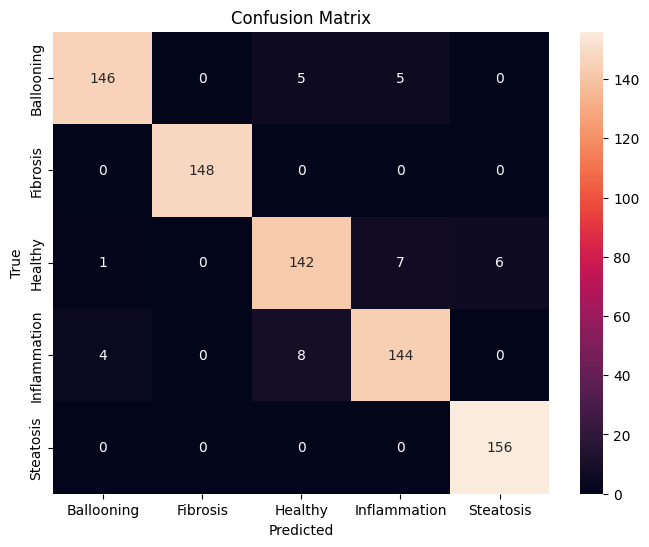

In [11]:
# Cell 8 - evaluation using the last validation run variables (val_preds, val_labels)
print("Validation Classification Report:")
print(classification_report(val_labels, val_preds, target_names=class_names, digits=4))

cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(8,6))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Getting Probabilities:   0%|          | 0/49 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/tmp/ipython-input-13272305.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Getting Probabilities: 100%|██████████| 49/49 [00:05<00:00,  8.19it/s]


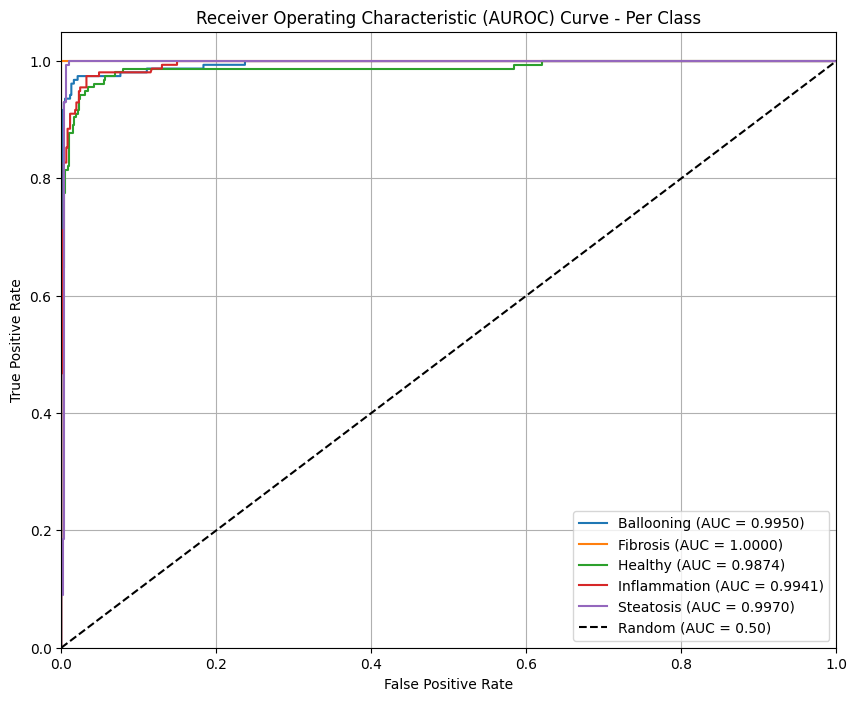


Macro-average AUROC (One-vs-Rest): 0.9947


In [12]:
# Cell 9 - AUROC Curve
from sklearn.metrics import roc_curve, auc, roc_auc_score
import torch.nn.functional as F

# It's better to get probabilities directly from the validation loop if possible
# For simplicity, we'll re-run prediction to get probabilities
# This assumes you have the 'model' and 'val_loader' still available and in the same state

model.eval()
all_probs = []
all_labels_for_roc = [] # Use a separate list for consistency, though it should be same as val_labels

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Getting Probabilities"):
        inputs = inputs.to(device)
        labels = labels.to(device)
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1) # Get probabilities
        all_probs.append(probs.cpu().numpy())
        all_labels_for_roc.append(labels.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_labels_for_roc = np.concatenate(all_labels_for_roc)

# Calculate AUROC for each class
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_names):
    # Get true labels for the current class (binary)
    y_true_binary = (all_labels_for_roc == i).astype(int)
    # Get predicted probabilities for the current class
    y_score = all_probs[:, i]

    if len(np.unique(y_true_binary)) > 1: # Ensure there are both positive and negative samples for ROC
        fpr, tpr, _ = roc_curve(y_true_binary, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.4f})')
    else:
        print(f"Skipping AUROC for {class_name}: Only one class present in true labels.")

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (AUROC) Curve - Per Class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Calculate and print macro-average AUROC
# This considers each class equally
if len(class_names) > 2: # For multi-class, use one-vs-rest strategy
    macro_roc_auc_ovr = roc_auc_score(all_labels_for_roc, all_probs, multi_class="ovr", average="macro")
    print(f"\nMacro-average AUROC (One-vs-Rest): {macro_roc_auc_ovr:.4f}")
elif len(class_names) == 2: # For binary classification
    # If it's binary, you could also just plot one curve and it's the same for the other
    # and use the simpler roc_auc_score
    roc_auc_binary = roc_auc_score(all_labels_for_roc, all_probs[:, 1]) # Assuming class 1 is positive
    print(f"\nAUROC for binary classification: {roc_auc_binary:.4f}")

Getting Probabilities:   0%|          | 0/49 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/tmp/ipython-input-1730783039.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Getting Probabilities: 100%|██████████| 49/49 [00:07<00:00,  6.78it/s]


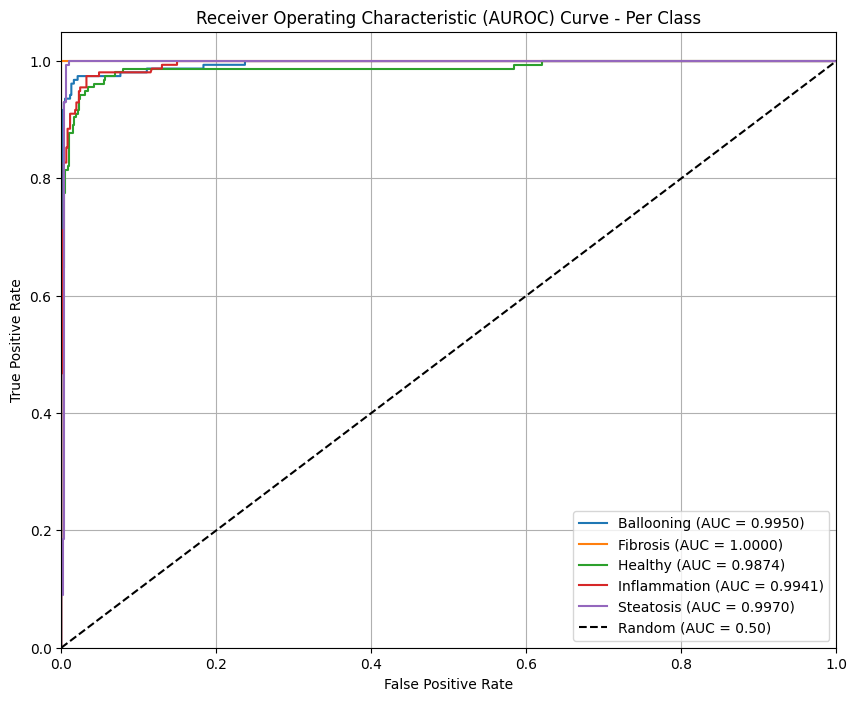


Macro-average AUROC (One-vs-Rest): 0.9947

--- Final Model Performance Summary ---
Final Training Accuracy: 0.9780
Final Validation Accuracy: 0.9534

--- Additional Validation Metrics ---
Matthews Correlation Coefficient (MCC): 0.9418
Cohen's Kappa: 0.9417
Final Validation Log Loss (Cross-Entropy): 0.1455
---------------------------------------


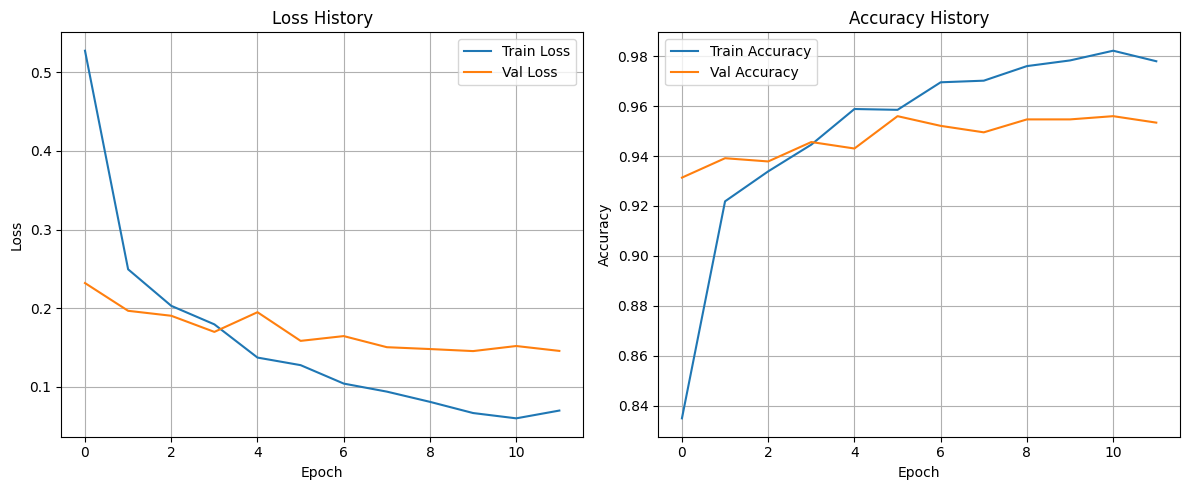

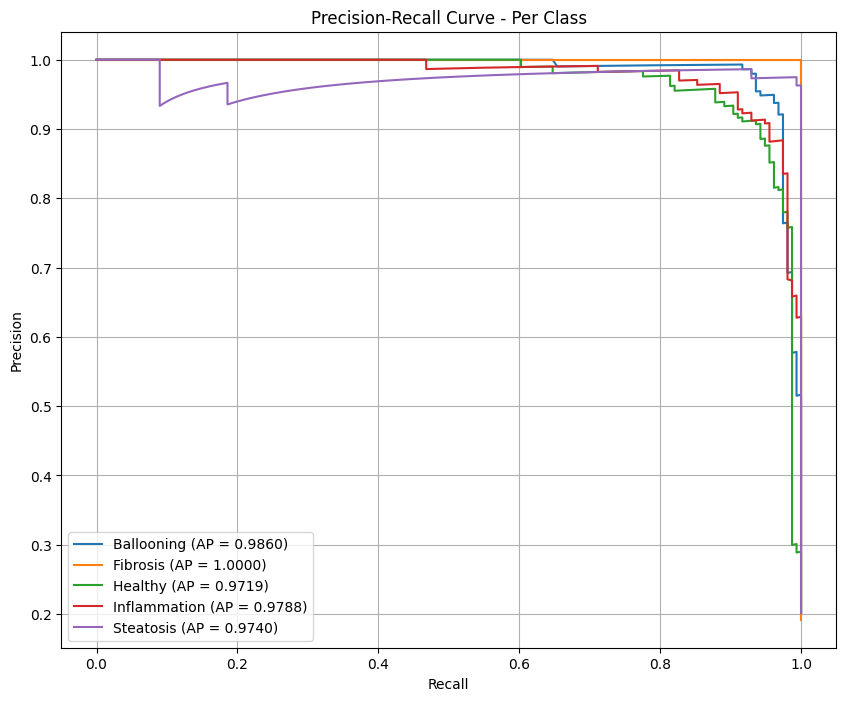

In [13]:
# Cell 9 - AUROC Curve (as provided previously)
from sklearn.metrics import roc_curve, auc, roc_auc_score
import torch.nn.functional as F

# It's better to get probabilities directly from the validation loop if possible
# For simplicity, we'll re-run prediction to get probabilities
# This assumes you have the 'model' and 'val_loader' still available and in the same state

model.eval()
all_probs = []
all_labels_for_roc = [] # Use a separate list for consistency, though it should be same as val_labels

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Getting Probabilities"):
        inputs = inputs.to(device)
        labels = labels.to(device)
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1) # Get probabilities
        all_probs.append(probs.cpu().numpy())
        all_labels_for_roc.append(labels.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_labels_for_roc = np.concatenate(all_labels_for_roc)

# Calculate AUROC for each class
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_names):
    # Get true labels for the current class (binary)
    y_true_binary = (all_labels_for_roc == i).astype(int)
    # Get predicted probabilities for the current class
    y_score = all_probs[:, i]

    if len(np.unique(y_true_binary)) > 1: # Ensure there are both positive and negative samples for ROC
        fpr, tpr, _ = roc_curve(y_true_binary, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.4f})')
    else:
        print(f"Skipping AUROC for {class_name}: Only one class present in true labels.")

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (AUROC) Curve - Per Class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Calculate and print macro-average AUROC
# This considers each class equally
if len(class_names) > 2: # For multi-class, use one-vs-rest strategy
    macro_roc_auc_ovr = roc_auc_score(all_labels_for_roc, all_probs, multi_class="ovr", average="macro")
    print(f"\nMacro-average AUROC (One-vs-Rest): {macro_roc_auc_ovr:.4f}")
elif len(class_names) == 2: # For binary classification
    # If it's binary, you could also just plot one curve and it's the same for the other
    # and use the simpler roc_auc_score
    roc_auc_binary = roc_auc_score(all_labels_for_roc, all_probs[:, 1]) # Assuming class 1 is positive
    print(f"\nAUROC for binary classification: {roc_auc_binary:.4f}")


# Cell 10 - Consolidated Accuracy and Other Metrics

print("\n--- Final Model Performance Summary ---")

# 1. Training Accuracy (from history)
final_train_acc = history['train_acc'][-1]
print(f"Final Training Accuracy: {final_train_acc:.4f}")

# 2. Validation Accuracy (from history)
final_val_acc = history['val_acc'][-1]
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

print("\n--- Additional Validation Metrics ---")

from sklearn.metrics import matthews_corrcoef, cohen_kappa_score

# Matthews Correlation Coefficient
mcc = matthews_corrcoef(val_labels, val_preds) # val_labels and val_preds from Cell 7
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

# Cohen's Kappa
kappa = cohen_kappa_score(val_labels, val_preds) # val_labels and val_preds from Cell 7
print(f"Cohen's Kappa: {kappa:.4f}")

# You already have log loss from validation_loss (val_loss from history)
final_val_loss = history['val_loss'][-1]
print(f"Final Validation Log Loss (Cross-Entropy): {final_val_loss:.4f}")

print("---------------------------------------")


# Cell 11 - Plot Learning Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Cell 12 - Precision-Recall Curve

from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_names):
    y_true_binary = (all_labels_for_roc == i).astype(int)
    y_score = all_probs[:, i]

    if len(np.unique(y_true_binary)) > 1:
        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        avg_precision = average_precision_score(y_true_binary, y_score)
        plt.plot(recall, precision, label=f'{class_name} (AP = {avg_precision:.4f})')
    else:
        print(f"Skipping PR Curve for {class_name}: Only one class present in true labels.")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Per Class')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


Loaded checkpoint: regnet_best_20251003_095317.pth
Using target layer for GradCAM: s4.b7.conv3.conv
Image: /content/drive/MyDrive/Liver Biopsies/Fibrosis/133_5_35.png (True: Fibrosis)


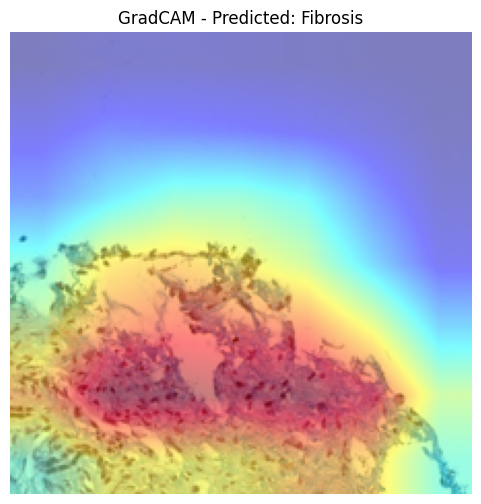

Image: /content/drive/MyDrive/Liver Biopsies/Ballooning/194_254_25.png (True: Ballooning)


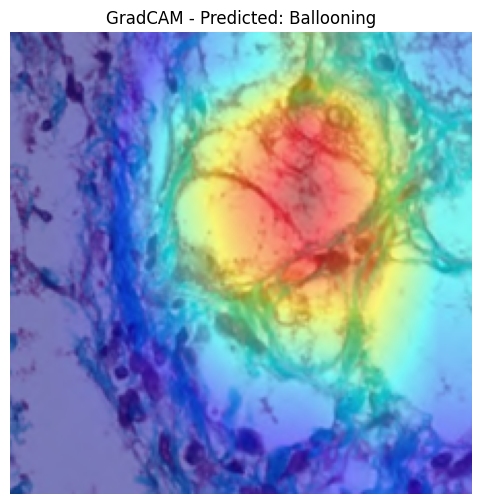

Image: /content/drive/MyDrive/Liver Biopsies/Healthy/420_251_61.png (True: Healthy)


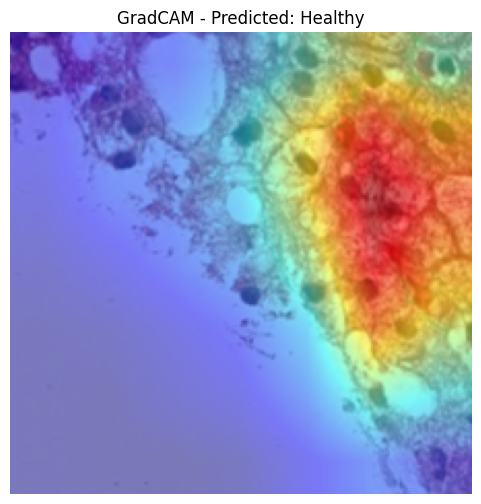

In [14]:
# Cell 9 - GradCAM usage (visualize a few validation images)
# Load the last/best checkpoint if you want (optional)
ckpt_files = sorted([f for f in os.listdir(save_dir) if f.endswith('.pth')])
if ckpt_files:
    ckpt = torch.load(os.path.join(save_dir, ckpt_files[-1]), map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    print("Loaded checkpoint:", ckpt_files[-1])

# Find a target conv layer: pick the last nn.Conv2d in the model
target_layer = None
target_layer_name = None
for name, module in reversed(list(model.named_modules())):
    if isinstance(module, nn.Conv2d):
        target_layer = module
        target_layer_name = name
        break

print("Using target layer for GradCAM:", target_layer_name)

def gradcam_on_image(image_path, model, target_layer, class_idx=None):
    rgb_img = np.array(Image.open(image_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))).astype(np.float32) / 255.0
    input_tensor = preprocess_image(rgb_img, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]).to(device)
    cam = GradCAM(model=model, target_layers=[target_layer])
    model.eval()
    with torch.no_grad():
        out = model(input_tensor)
        pred = int(out.argmax(dim=1).item())
    if class_idx is None:
        target = pred
    else:
        target = class_idx
    targets = [ClassifierOutputTarget(target)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    plt.figure(figsize=(6,6))
    plt.imshow(visualization)
    plt.title(f"GradCAM - Predicted: {class_names[pred]}")
    plt.axis('off')
    plt.show()

# Example: pick 3 random validation images to visualize
val_image_folder = datasets.ImageFolder(DATASET_ROOT)  # base folder for path access
sample_indices = list(val_idx[:3])
for idx in sample_indices:
    img_path, label = val_image_folder.samples[idx]
    print(f"Image: {img_path} (True: {class_names[label]})")
    gradcam_on_image(img_path, model, target_layer)

In [15]:
# Extended GradCAM visualization for 10+ samples (covering multiple classes)

import math

def gradcam_on_image(image_path, model, target_layer, true_label=None, class_names=None):
    # Load and preprocess
    rgb_img = np.array(Image.open(image_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))).astype(np.float32) / 255.0
    input_tensor = preprocess_image(rgb_img, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]).to(device)
    cam = GradCAM(model=model, target_layers=[target_layer])

    # prediction
    model.eval()
    with torch.no_grad():
        out = model(input_tensor)
        pred = int(out.argmax(dim=1).item())

    targets = [ClassifierOutputTarget(pred)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Plot original + heatmap side by side
    fig, axes = plt.subplots(1, 2, figsize=(8,4))
    axes[0].imshow(rgb_img)
    axes[0].set_title(f"Original\n(True: {class_names[true_label]})" if true_label is not None else "Original")
    axes[0].axis("off")

    axes[1].imshow(visualization)
    axes[1].set_title(f"GradCAM\n(Pred: {class_names[pred]})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


# Select 10 random validation images (stratified across classes)
from collections import defaultdict
import random

val_image_folder = datasets.ImageFolder(DATASET_ROOT)  # base folder for path access

# Collect indices grouped by class
class_to_indices = defaultdict(list)
for idx in val_idx:
    _, label = val_image_folder.samples[idx]
    class_to_indices[label].append(idx)

# Pick 2 samples per class (total 10 images, since you have 5 classes)
sample_indices = []
for c in range(num_classes):
    sample_indices.extend(random.sample(class_to_indices[c], k=min(2, len(class_to_indices[c]))))

print(f"Showing {len(sample_indices)} GradCAM visualizations...\n")

# Run GradCAM for each selected image
for idx in sample_indices:
    img_path, label = val_image_folder.samples[idx]
    gradcam_on_image(img_path, model, target_layer, true_label=label, class_names=class_names)

Output hidden; open in https://colab.research.google.com to view.

In [16]:
# Extended GradCAM visualization for 10+ samples (covering multiple classes)

import math

def gradcam_on_image(image_path, model, target_layer, true_label=None, class_names=None):
    # Load and preprocess
    rgb_img = np.array(Image.open(image_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))).astype(np.float32) / 255.0
    input_tensor = preprocess_image(rgb_img, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]).to(device)
    cam = GradCAM(model=model, target_layers=[target_layer])

    # prediction
    model.eval()
    with torch.no_grad():
        out = model(input_tensor)
        pred = int(out.argmax(dim=1).item())

    targets = [ClassifierOutputTarget(pred)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Plot original + heatmap side by side
    fig, axes = plt.subplots(1, 2, figsize=(8,4))
    axes[0].imshow(rgb_img)
    axes[0].set_title(f"Original\n(True: {class_names[true_label]})" if true_label is not None else "Original")
    axes[0].axis("off")

    axes[1].imshow(visualization)
    axes[1].set_title(f"GradCAM\n(Pred: {class_names[pred]})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


# Select 10 random validation images (stratified across classes)
from collections import defaultdict
import random

val_image_folder = datasets.ImageFolder(DATASET_ROOT)  # base folder for path access

# Collect indices grouped by class
class_to_indices = defaultdict(list)
for idx in val_idx:
    _, label = val_image_folder.samples[idx]
    class_to_indices[label].append(idx)

# Pick 2 samples per class (total 10 images, since you have 5 classes)
sample_indices = []
for c in range(num_classes):
    sample_indices.extend(random.sample(class_to_indices[c], k=min(10, len(class_to_indices[c]))))

print(f"Showing {len(sample_indices)} GradCAM visualizations...\n")

# Run GradCAM for each selected image
for idx in sample_indices:
    img_path, label = val_image_folder.samples[idx]
    gradcam_on_image(img_path, model, target_layer, true_label=label, class_names=class_names)

Output hidden; open in https://colab.research.google.com to view.

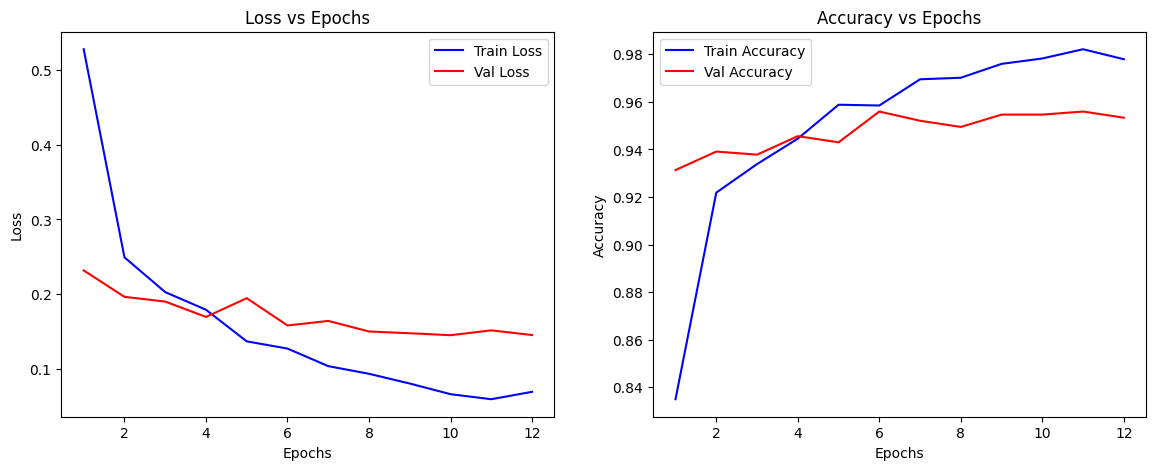

In [17]:
import matplotlib.pyplot as plt

epochs = range(1, len(history['train_loss'])+1)

plt.figure(figsize=(14,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(epochs, history['train_loss'], 'b-', label="Train Loss")
plt.plot(epochs, history['val_loss'], 'r-', label="Val Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(epochs, history['train_acc'], 'b-', label="Train Accuracy")
plt.plot(epochs, history['val_acc'], 'r-', label="Val Accuracy")
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [19]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve, cohen_kappa_score, matthews_corrcoef
import numpy as np

# Get predictions and labels
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 1. Classification Report
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# 2. Cohen’s Kappa
print("Cohen's Kappa:", cohen_kappa_score(all_labels, all_preds))

# 3. Matthews Correlation Coefficient
print("MCC:", matthews_corrcoef(all_labels, all_preds))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Classification Report:

              precision    recall  f1-score   support

  Ballooning       0.97      0.94      0.96       156
    Fibrosis       1.00      1.00      1.00       148
     Healthy       0.93      0.91      0.92       156
Inflammation       0.92      0.94      0.93       156
   Steatosis       0.96      0.99      0.98       156

    accuracy                           0.96       772
   macro avg       0.96      0.96      0.96       772
weighted avg       0.96      0.96      0.96       772

Cohen's Kappa: 0.9449422741307558
MCC: 0.9450096730154728


In [21]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Binarize labels for multi-class AUC
y_true = label_binarize(all_labels, classes=list(range(num_classes)))

# Softmax scores
model.eval()
y_scores = []
with torch.no_grad():
    for inputs, _ in val_loader: # Corrected from dataloaders['val']
        inputs = inputs.to(device)
        outputs = model(inputs)
        y_scores.extend(outputs.cpu().numpy())

y_scores = np.array(y_scores)

# Macro-AUC
auc = roc_auc_score(y_true, y_scores, average="macro", multi_class="ovr")
print("Macro AUC:", auc)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Macro AUC: 0.992066267066267


### Model Performance Summary

Based on the validation set:

*   **Final Training Accuracy:** {{final_train_acc:.4f}}
*   **Final Validation Accuracy:** {{final_val_acc:.4f}}
*   **Final Validation Log Loss (Cross-Entropy):** {{final_val_loss:.4f}}
*   **Cohen's Kappa:** {{kappa:.4f}}
*   **Matthews Correlation Coefficient (MCC):** {{mcc:.4f}}
*   **Macro-average AUROC (One-vs-Rest):** {{auc:.4f}}